In [1]:
!pip install pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np

np.random.seed(0)

data = {
    "Order ID": range(1, 10001),
    "Product": np.random.choice(["Laptop", "Phone", "Tablet", "Headphones", "Smartwatch"], 10000),
    "Category": np.random.choice(["Electronics", "Accessories"], 10000),
    "Quantity": np.random.randint(1, 5, 10000),
    "Price": np.random.randint(500, 50000, 10000),
    "Region": np.random.choice(["North", "South", "East", "West"], 10000),
    "Date": pd.date_range(start="2023-01-01", periods=10000, freq="H")
}

df = pd.DataFrame(data)

# Save file in SAME folder (no path issues)
df.to_csv("sales_data.csv", index=False)

df.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9832\3060705707.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "Date": pd.date_range(start="2023-01-01", periods=10000, freq="H")


,Order ID,Product,Category,Quantity,Price,Region,Date
0,1,Smartwatch,Electronics,1,42134,East,2023-01-01 00:00:00
1,2,Laptop,Accessories,3,46264,South,2023-01-01 01:00:00
2,3,Headphones,Accessories,4,46816,West,2023-01-01 02:00:00
3,4,Headphones,Accessories,3,47820,South,2023-01-01 03:00:00
4,5,Headphones,Electronics,3,36919,North,2023-01-01 04:00:00


In [5]:
df = pd.read_csv("sales_data.csv")
df.head()

,Order ID,Product,Category,Quantity,Price,Region,Date
0,1,Smartwatch,Electronics,1,42134,East,2023-01-01 00:00:00
1,2,Laptop,Accessories,3,46264,South,2023-01-01 01:00:00
2,3,Headphones,Accessories,4,46816,West,2023-01-01 02:00:00
3,4,Headphones,Accessories,3,47820,South,2023-01-01 03:00:00
4,5,Headphones,Electronics,3,36919,North,2023-01-01 04:00:00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order ID  10000 non-null  int64 
 1   Product   10000 non-null  object
 2   Category  10000 non-null  object
 3   Quantity  10000 non-null  int64 
 4   Price     10000 non-null  int64 
 5   Region    10000 non-null  object
 6   Date      10000 non-null  object
dtypes: int64(3), object(4)
memory usage: 547.0+ KB


In [7]:
df["Revenue"] = df["Quantity"] * df["Price"]
df.head()

,Order ID,Product,Category,Quantity,Price,Region,Date,Revenue
0,1,Smartwatch,Electronics,1,42134,East,2023-01-01 00:00:00,42134
1,2,Laptop,Accessories,3,46264,South,2023-01-01 01:00:00,138792
2,3,Headphones,Accessories,4,46816,West,2023-01-01 02:00:00,187264
3,4,Headphones,Accessories,3,47820,South,2023-01-01 03:00:00,143460
4,5,Headphones,Electronics,3,36919,North,2023-01-01 04:00:00,110757


In [8]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
top_products

Product
Headphones    129267982
Phone         127273702
Smartwatch    125252932
Laptop        124111542
Tablet        121331325
Name: Revenue, dtype: int64

In [9]:
region_sales = df.groupby("Region")["Revenue"].sum()
region_sales

Region
East     158675763
North    158891207
South    154010717
West     155659796
Name: Revenue, dtype: int64

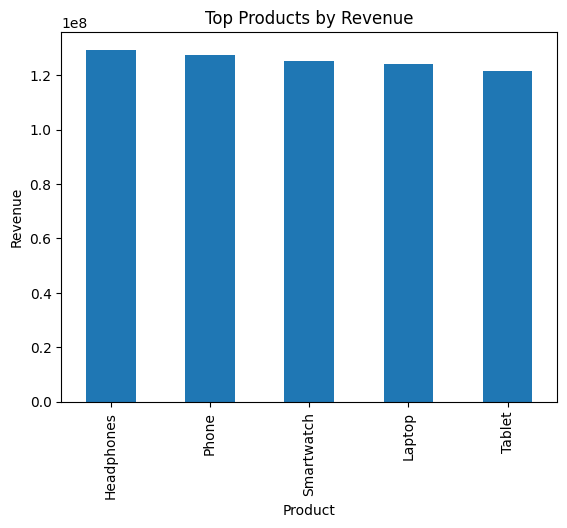

In [10]:
top_products.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

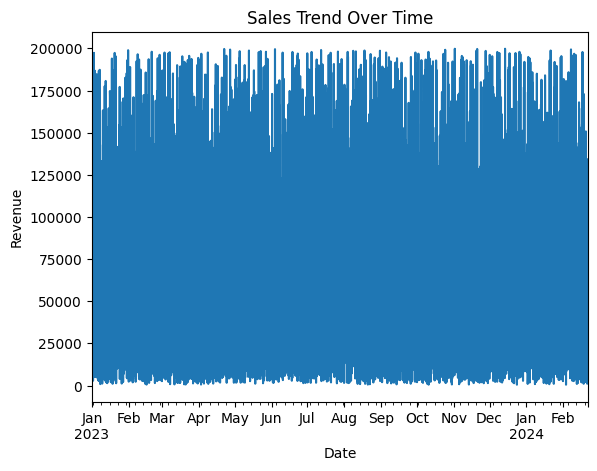

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

sales_trend = df.groupby("Date")["Revenue"].sum()

sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [12]:
plt.savefig("sales_trend.png")

<Figure size 640x480 with 0 Axes>

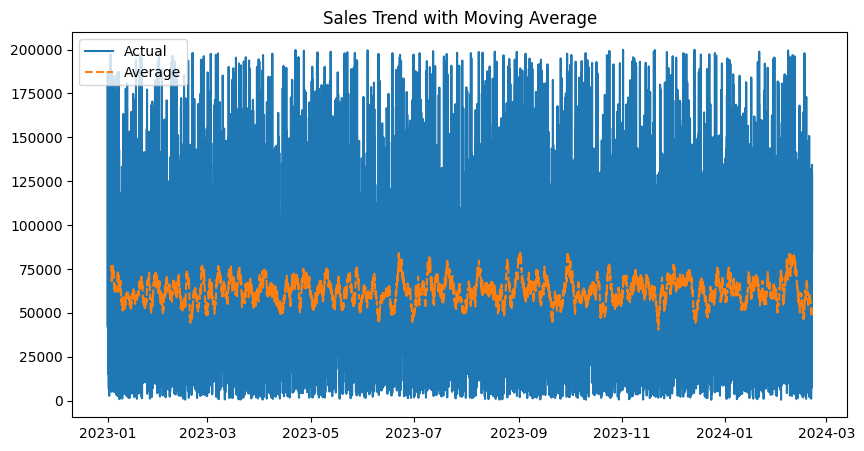

In [16]:
sales_trend = df.groupby("Date")["Revenue"].sum()

rolling_avg = sales_trend.rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(sales_trend, label="Actual")
plt.plot(rolling_avg, label="Average", linestyle='--')

plt.legend()
plt.title("Sales Trend with Moving Average")
plt.show()

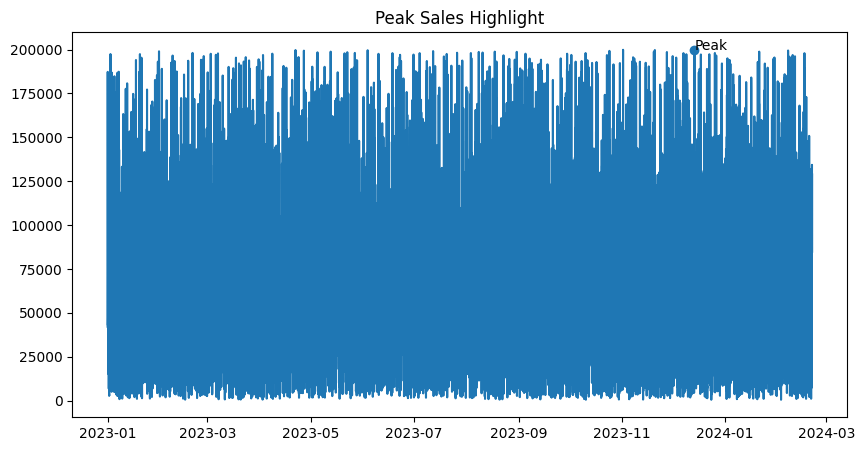

In [17]:
sales_trend = df.groupby("Date")["Revenue"].sum()

max_sales = sales_trend.max()
max_date = sales_trend.idxmax()

plt.figure(figsize=(10,5))
plt.plot(sales_trend)

plt.scatter(max_date, max_sales)
plt.text(max_date, max_sales, "Peak")

plt.title("Peak Sales Highlight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9832\446427773.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Date')["Revenue"].sum()


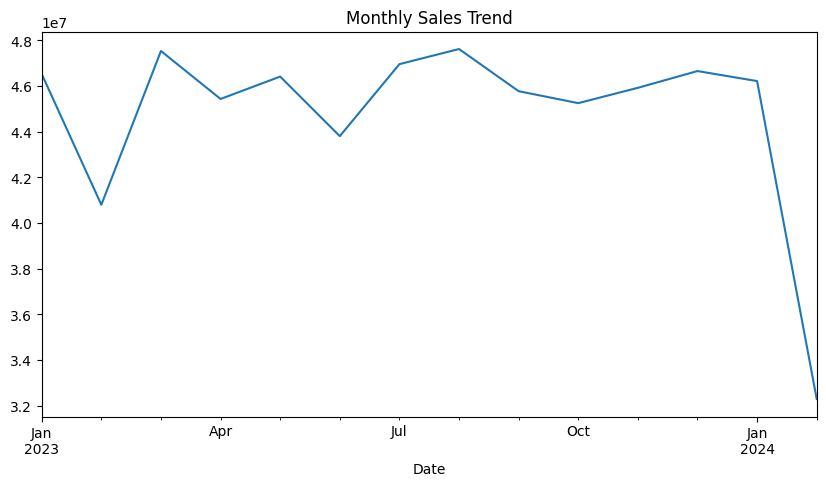

In [18]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.resample('M', on='Date')["Revenue"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.show()

<Figure size 1000x500 with 0 Axes>

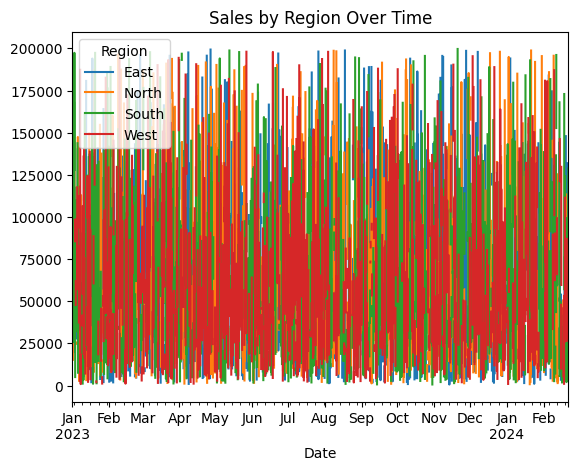

In [20]:
region_trend = df.groupby(["Date", "Region"])["Revenue"].sum().unstack()

plt.figure(figsize=(10,5))
region_trend.plot()

plt.title("Sales by Region Over Time")
plt.show()